In [1]:
import pandas as pd
import os
import sys
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Define number of observations and generate a date range
n = 500
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

# Create components for the synthetic data:
# - A linear trend
trend = np.linspace(0, 10, n)

# - A seasonal component using a sine wave
seasonality = 5 * np.sin(np.linspace(0, 3 * np.pi, n))

# - Random noise
noise = np.random.normal(0, 1, n)

# Combine all components to form the time series data
data = trend + seasonality + noise

# Create a DataFrame
data = pd.DataFrame({'Date': dates, 'Value': data})

In [3]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.head()

,Value
Date,
2020-01-01,0.496714
2020-01-02,-0.023793
2020-01-03,0.876597
2020-01-04,1.866308
2020-01-05,0.223394


Outliers:
Empty DataFrame
Columns: [Value]
Index: []


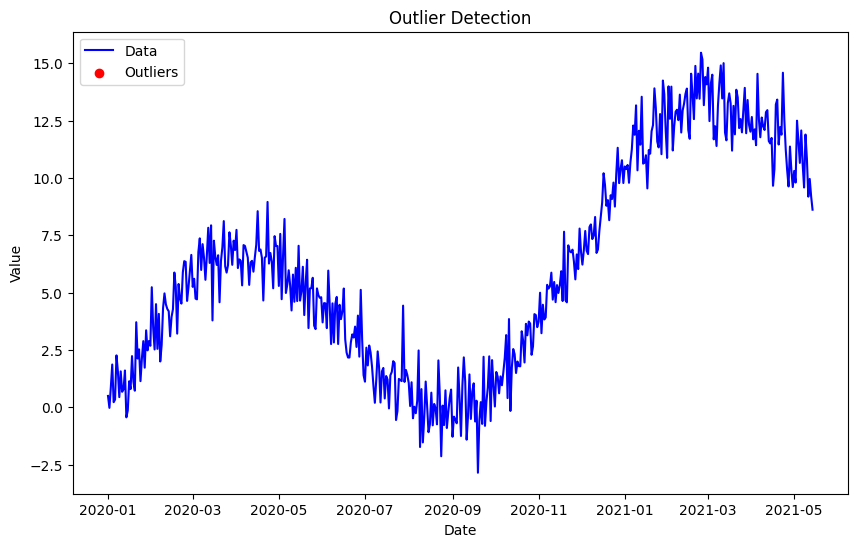

In [4]:
# Calculate the IQR
Q1 = data['Value'].quantile(0.25)
Q3 = data['Value'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data['Value'] < lower_bound) | (data['Value'] > upper_bound)]

# Print the outliers
print("Outliers:")
print(outliers)

# Plot the data with outliers highlighted
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Value'], label='Data', color='blue')
plt.scatter(outliers.index, outliers['Value'], color='red', label='Outliers')
plt.title('Outlier Detection')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

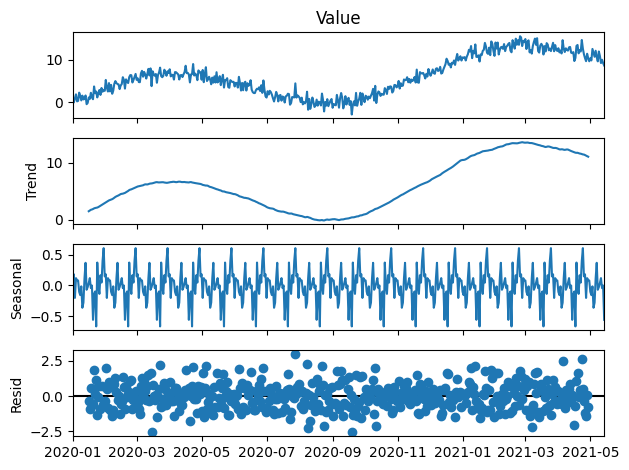

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure there are no missing values in the data
data_cleaned = data['Value'].dropna()

# Perform seasonal decomposition
result = seasonal_decompose(data_cleaned, model='additive', period=30)

# Plot the decomposition
result.plot()
plt.show()

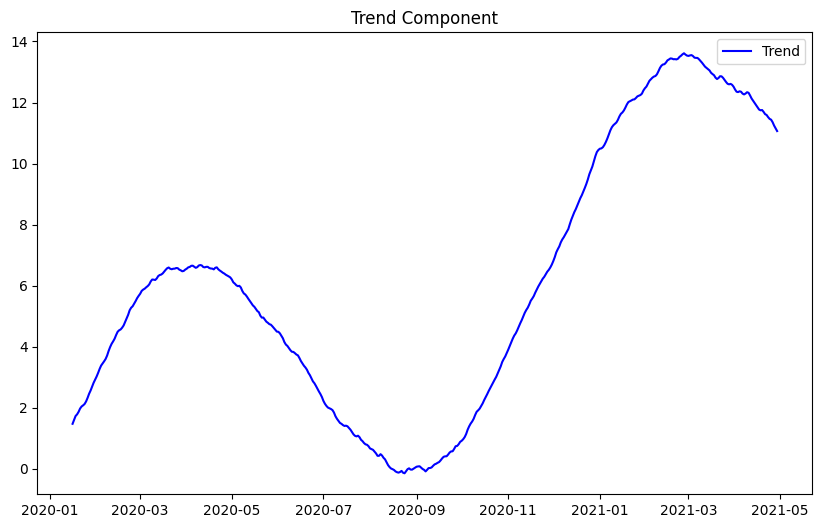

In [6]:
# Extract and plot the trend component
trend = result.trend
plt.figure(figsize=(10, 6))
plt.plot(trend, label='Trend', color='blue')
plt.title('Trend Component')
plt.legend()
plt.show()

ADF Statistic: -0.9683929612400907
p-value: 0.7646170199770999
The series is non-stationary after 0 differencing(s). Differencing again...
The series is still non-stationary after 1 differencing(s).


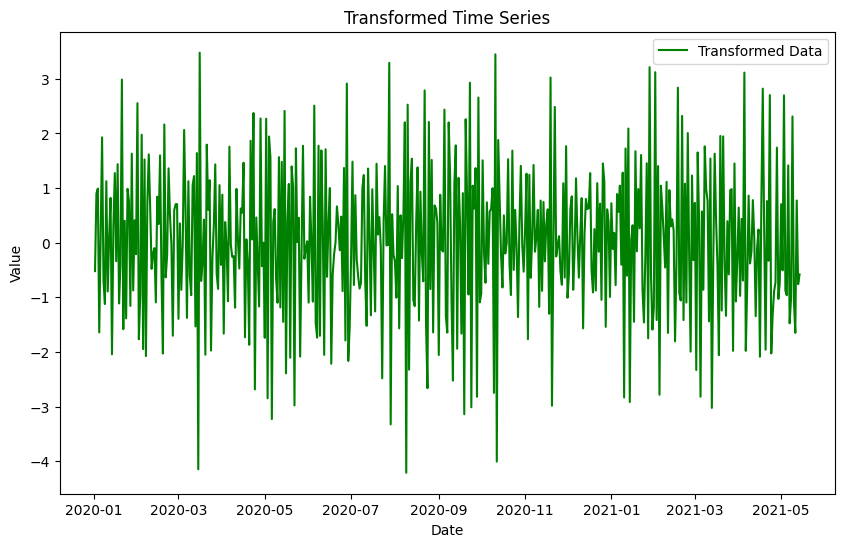

In [7]:
from statsmodels.tsa.stattools import adfuller

def make_stationary(data, column, max_diff=1):

    for i in range(max_diff):
        # Perform the Augmented Dickey-Fuller test
        adf_test = adfuller(data[column].dropna())
        print(f"ADF Statistic: {adf_test[0]}")
        print(f"p-value: {adf_test[1]}")
        p_value = adf_test[1]
        key = '5%'

        # Check if the series is stationary
        if p_value <= 0.05 and adf_test[0] < adf_test[4][key]:
            print(f"The series is stationary after {i} differencing(s).")
            break
        else:
            print(f"The series is non-stationary after {i} differencing(s). Differencing again...")
            data[column] = data[column].diff().dropna()
            data.dropna(inplace=True)
    else:
        print(f"The series is still non-stationary after {max_diff} differencing(s).")

    return data

# Apply the pipeline to the data
data = make_stationary(data, 'Value', max_diff=1)

# Plot the final differenced data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Value'], label='Transformed Data', color='green')
plt.title('Transformed Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [8]:
data = data.diff(12).dropna()  # Seasonal differencing (e.g., for monthly data)

First significant ACF lag: 1
First significant PACF lag: 1


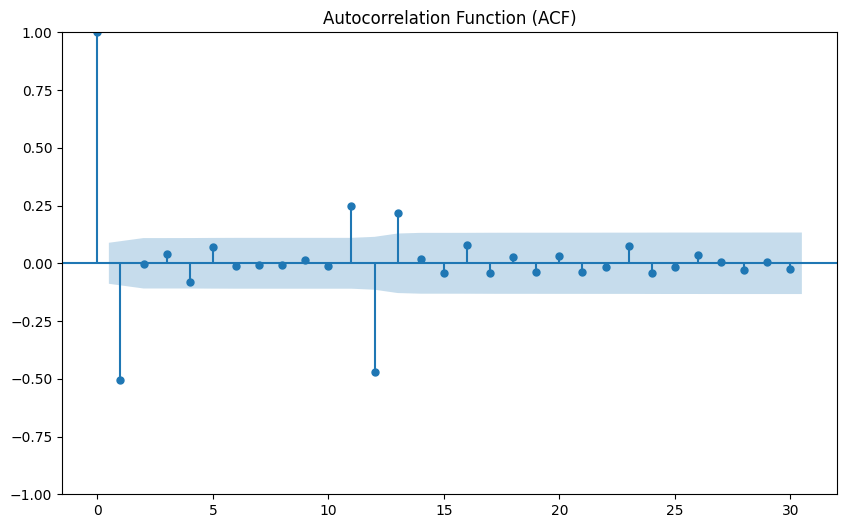

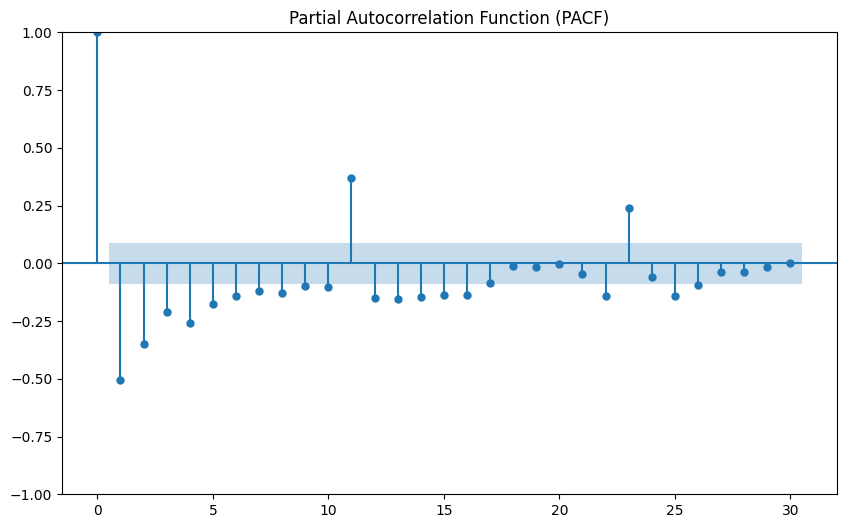

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_acf_pacf(data, acf_values, pacf_values, conf_level):

    # Calculate first significant ACF lag (excluding lag 0)
    first_sig_acf_lag = next(i for i, val in enumerate(acf_values[1:], start=1) if abs(val) > conf_level)

    # Calculate first significant PACF lag
    first_sig_pacf_lag = next(i for i, val in enumerate(pacf_values[1:], start=1) if abs(val) > conf_level)

    print(f"First significant ACF lag: {first_sig_acf_lag}")
    print(f"First significant PACF lag: {first_sig_pacf_lag}")

    # Plot the autocorrelation function (ACF)
    plt.figure(figsize=(10, 6))
    plot_acf(data['Value'], lags=30, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')
    plt.show()

    # Plot the partial autocorrelation function (PACF)
    plt.figure(figsize=(10, 6))
    plot_pacf(data['Value'], lags=30, ax=plt.gca(), method='ywm')
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.show()

    return {
        "first_sig_acf_lag": first_sig_acf_lag,
        "first_sig_pacf_lag": first_sig_pacf_lag
}

from statsmodels.tsa.stattools import acf, pacf

# Calculate ACF and PACF values
acf_values = acf(data['Value'], nlags=30)
pacf_values = pacf(data['Value'], nlags=30, method='ywm')

# Define a confidence level (e.g., 0.2 for 20%)
conf_level = 0.2

# Call the function with the calculated values
results = analyze_acf_pacf(data, acf_values, pacf_values, conf_level)

### Interpreting ACF and PACF Plots

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are essential tools in time series analysis, particularly for identifying the order of ARIMA models.

---

#### 1. **Autocorrelation Function (ACF)**
- **Definition**: ACF measures the correlation between the time series and its lagged values.
- **Purpose**: Helps identify the order of the Moving Average (MA) component in an ARIMA model.
- **Interpretation**:
  - Significant spikes at lag `k` indicate that the lagged value at `k` is correlated with the current value.
  - A gradual decay in the ACF plot suggests the presence of a non-stationary series.
  - A sharp cutoff after a few lags indicates the order of the MA component.

---

#### 2. **Partial Autocorrelation Function (PACF)**
- **Definition**: PACF measures the correlation between the time series and its lagged values, after removing the effects of intermediate lags.
- **Purpose**: Helps identify the order of the Auto-Regressive (AR) component in an ARIMA model.
- **Interpretation**:
  - Significant spikes at lag `k` indicate that the lagged value at `k` contributes to the series after accounting for intermediate lags.
  - A sharp cutoff in the PACF plot suggests the order of the AR component.

---

#### 3. **Key Patterns to Look For**
- **Stationary Series**:
  - **ACF**: Rapid decay to zero.
  - **PACF**: Rapid decay to zero.
- **Non-Stationary Series**:
  - **ACF**: Slow decay or sinusoidal pattern.
  - **PACF**: Significant spikes at initial lags.
- **AR Process**:
  - **ACF**: Gradual decay.
  - **PACF**: Sharp cutoff after `p` lags.
- **MA Process**:
  - **ACF**: Sharp cutoff after `q` lags.
  - **PACF**: Gradual decay.

---

#### 4. **Practical Tips**
- Use the **ACF plot** to determine the order of the MA component (`q`).
- Use the **PACF plot** to determine the order of the AR component (`p`).
- If the series is non-stationary, consider differencing it before analyzing the ACF and PACF plots.

In [10]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

In [11]:
metrics_df = pd.DataFrame(columns=["Order", "Seasonal_Order", "MAE", "MSE", "RMSE", "MAPE", "R2"])
try:
    if not isinstance(metrics_storage, list):
        metrics_storage = []
except NameError:
    metrics_storage = []

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define a range of SARIMA orders for grid search
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)
P_values = range(0, 2)
D_values = range(0, 2)
Q_values = range(0, 2)
s_values = [7, 12]

best_aic = float("inf")
best_order = None
best_seasonal_order = None

# Perform grid search
for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        for s in s_values:
                            try:
                                model = SARIMAX(train['Value'],
                                                order=(p, d, q),
                                                seasonal_order=(P, D, Q, s),
                                                enforce_stationarity=False,
                                                enforce_invertibility=False)
                                result = model.fit(disp=False)
                                if result.aic < best_aic:
                                    best_aic = result.aic
                                    best_order = (p, d, q)
                                    best_seasonal_order = (P, D, Q, s)
                            except Exception as e:
                                continue

# Set the best order and seasonal order
order = best_order
seasonal_order = best_seasonal_order

print(f"Best SARIMA Order: {order}")
print(f"Best Seasonal Order: {seasonal_order}")
print(f"Best AIC: {best_aic}")

# Fit a SARIMA model
sarima_model = SARIMAX(train['Value'], 
                       order=order, 
                       seasonal_order=seasonal_order, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Print the summary of the SARIMA model
print(sarima_result.summary())
import plotly.graph_objects as go

# Create an interactive plot
fig = go.Figure()

# Add observed data
fig.add_trace(go.Scatter(x=data.index, y=data['Value'], mode='lines', name='Observed', line=dict(color='blue')))

# Generate forecasted values for the next 30 days
forecast = sarima_result.get_forecast(steps=30)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Add forecasted values
fig.add_trace(go.Scatter(x=forecast_values.index, y=forecast_values, mode='lines', name='Forecast', line=dict(color='orange')))

# Add confidence intervals
fig.add_trace(go.Scatter(
    x=confidence_intervals.index.tolist() + confidence_intervals.index[::-1].tolist(),
    y=confidence_intervals.iloc[:, 0].tolist() + confidence_intervals.iloc[:, 1][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(128, 128, 128, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

# Update layout for clarity
fig.update_layout(
    title='30-Day Forecasted Threat Event Count',
    xaxis_title='Date',
    yaxis_title='Threat Event Count',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white'
)

# Show the interactive plot
fig.show()
predictions = sarima_result.predict(start=test.index[0], end=test.index[-1])


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: Val

Best SARIMA Order: (0, 1, 3)
Best Seasonal Order: (0, 0, 1, 12)
Best AIC: 1123.612072506854


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  389
Model:             SARIMAX(0, 1, 3)x(0, 0, [1], 12)   Log Likelihood                -556.806
Date:                              Tue, 01 Apr 2025   AIC                           1123.612
Time:                                      10:46:19   BIC                           1143.207
Sample:                                  01-14-2020   HQIC                          1131.394
                                       - 02-05-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.1550      0.086    -25.112      0.000      -2.323      -1.987
ma.L2          1.22

MAE: 1.5547
MSE: 3.5776
RMSE: 1.8915
MAPE: 93.98%
R² Score: 0.0845
Order: (0, 1, 3)
Seasonal Order: (0, 0, 1, 12)

Model Fit Evaluation:
Model needs improvement.

Overfitting Check:
Train MAE: 0.9286
Train RMSE: 1.2460
Test MAE: 1.5547
Test RMSE: 1.8915
The model may be overfitting to the training data.


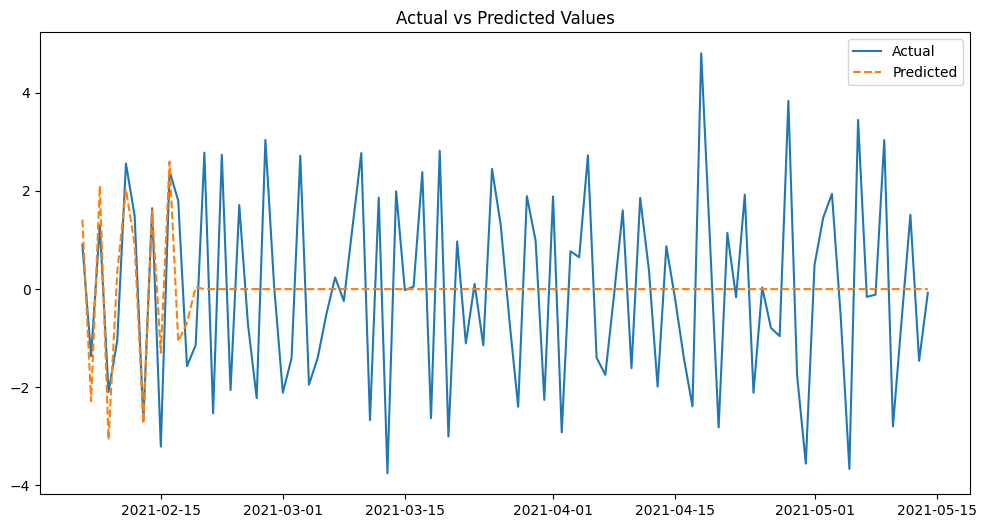

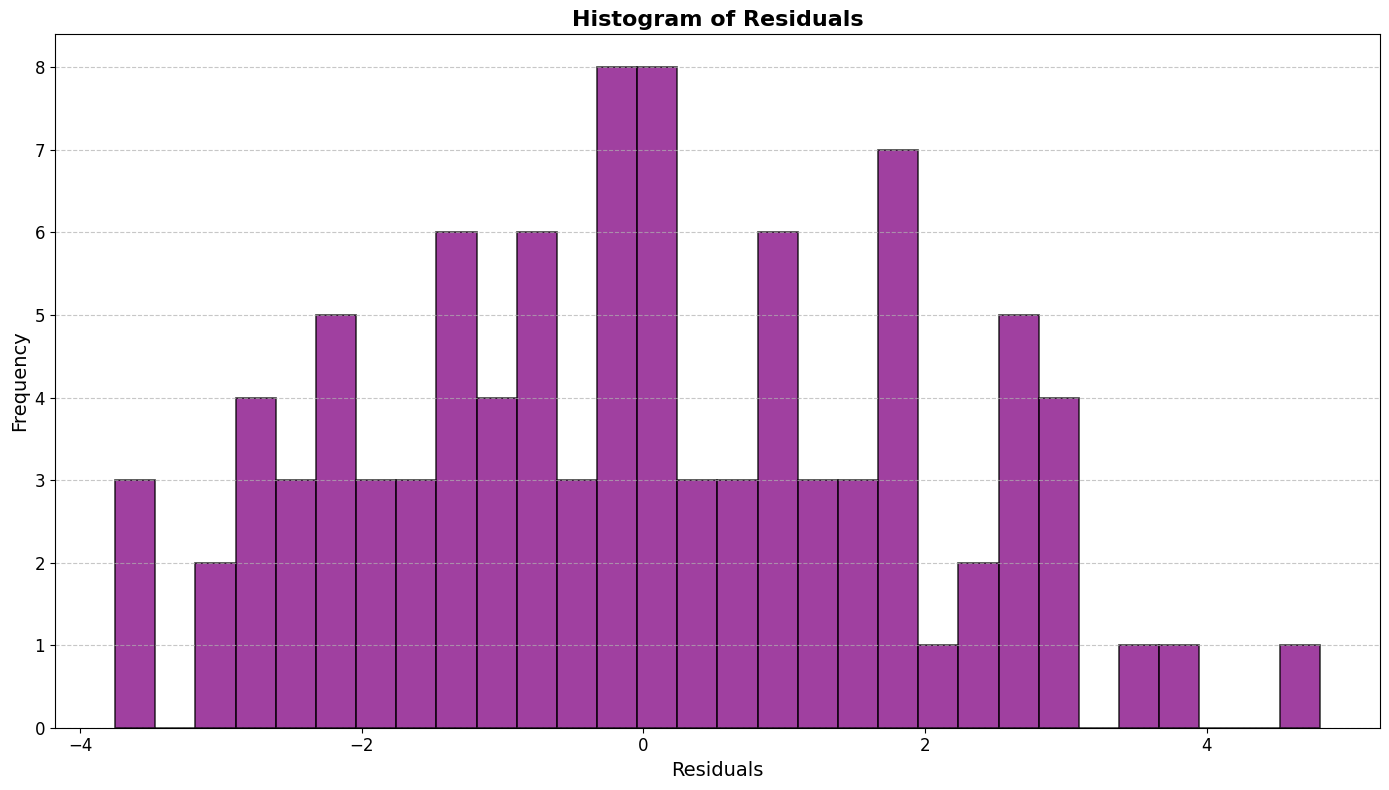

Shapiro-Wilk Test Statistic: 0.9845, p-value: 0.3065
Shapiro-Wilk Test: Residuals appear to be normally distributed.
D'Agostino and Pearson's Test Statistic: 3.7011, p-value: 0.1572
D'Agostino and Pearson's Test: Residuals appear to be normally distributed.

Underfitting Check:
No significant underfitting detected.

Ljung-Box Test:
Ljung-Box Test Statistic: 28.4063, p-value: 0.0016
Ljung-Box Test: Residuals do not appear to be white noise.


In [13]:
# Initialize storage
current_order = None
current_seasonal_order = None
best_metrics = metrics_storage[-1] if metrics_storage else None
previous_metrics = best_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro, normaltest
from statsmodels.stats.diagnostic import acorr_ljungbox

def evaluate_model_pipeline(actual, predictions, order, seasonal_order):
    global current_metrics, current_order, current_seasonal_order, metrics_df, metrics_storage

    # Calculate metrics
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    espilon = 1e-5
    mape = np.mean(np.abs((actual - predictions) / (actual + espilon))) * 100
    r2 = r2_score(actual, predictions)

    current_metrics = {'Order': order, 'Seaonal_Order': seasonal_order, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

    # Define thresholds
    mae_thresh = actual.mean() * 0.1
    rmse_thresh = actual.std() * 0.5

    # Print metrics
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")
    print(f"Order: {order}")
    print(f"Seasonal Order: {seasonal_order}")
    print("\nModel Fit Evaluation:")

    if mae < mae_thresh and rmse < rmse_thresh:
        print("Model is highly accurate and has a good fit.")
    elif mae < mae_thresh * 2 and rmse < rmse_thresh * 2:
        print("Model is moderately accurate and has an acceptable fit.")
    else:
        print("Model needs improvement.")

    # Check for overfitting by comparing train and test performance
    train_predictions = sarima_result.predict(start=train.index[0], end=train.index[-1])
    train_mae = mean_absolute_error(train['Value'], train_predictions)
    train_rmse = np.sqrt(mean_squared_error(train['Value'], train_predictions))

    print("\nOverfitting Check:")
    print(f"Train MAE: {train_mae:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test RMSE: {rmse:.4f}")

    if train_mae < mae and train_rmse < rmse:
        print("The model may be overfitting to the training data.")
    else:
        print("No significant overfitting detected.")
    
    # Calculate total scores for comparison
    total_score_current = mae + mse + rmse
    total_score_best = (best_metrics['MAE'] + best_metrics['MSE'] + best_metrics['RMSE']) if best_metrics else float('inf')

    # Store metrics based on total score comparison
    if not metrics_storage:
        metrics_storage.append(current_metrics)
    elif total_score_current < total_score_best:
        print("New best model found!")
        metrics_storage.append(current_metrics)
          
    plt.figure(figsize=(12, 6))
    plt.plot(actual.index, actual, label='Actual')
    plt.plot(predictions.index, predictions, label='Predicted', linestyle='--')
    plt.legend()
    plt.title("Actual vs Predicted Values")
    plt.show()

    pd.set_option('display.width', 1000)  # Increase the width
    pd.set_option('display.max_columns', None)  # Ensure all columns are displayed

    # Calculate residuals
    residuals = actual - predictions

    # Plot histogram of residuals with improved quality
    plt.figure(figsize=(14, 8))
    plt.hist(residuals, bins=30, color='purple', alpha=0.75, edgecolor='black', linewidth=1.2)
    plt.title("Histogram of Residuals", fontsize=16, fontweight='bold')
    plt.xlabel("Residuals", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Check if residuals are normally distributed

    # Perform Shapiro-Wilk test
    shapiro_stat, shapiro_p = shapiro(residuals)
    print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("Shapiro-Wilk Test: Residuals appear to be normally distributed.")
    else:
        print("Shapiro-Wilk Test: Residuals do not appear to be normally distributed.")

    # Perform D'Agostino and Pearson's test
    dagostino_stat, dagostino_p = normaltest(residuals)
    print(f"D'Agostino and Pearson's Test Statistic: {dagostino_stat:.4f}, p-value: {dagostino_p:.4f}")
    if dagostino_p > 0.05:
        print("D'Agostino and Pearson's Test: Residuals appear to be normally distributed.")
    else:
        print("D'Agostino and Pearson's Test: Residuals do not appear to be normally distributed.")
    
    # Check for underfitting by comparing train and test performance
    print("\nUnderfitting Check:")
    if train_mae > mae and train_rmse > rmse:
        print("The model may be underfitting to the data.")
    else:
        print("No significant underfitting detected.")
        
    # Check if residuals are white noise using Ljung-Box test

    ljungbox_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print("\nLjung-Box Test:")
    print(f"Ljung-Box Test Statistic: {ljungbox_result['lb_stat'].iloc[0]:.4f}, p-value: {ljungbox_result['lb_pvalue'].iloc[0]:.4f}")
    if ljungbox_result['lb_pvalue'].iloc[0] > 0.05:
        print("Ljung-Box Test: Residuals appear to be white noise.")
    else:
        print("Ljung-Box Test: Residuals do not appear to be white noise.")
        
metrics = evaluate_model_pipeline(test['Value'], predictions, order, seasonal_order)




### Interpretation of Metrics

#### MAE, MSE, RMSE:
- These metrics measure the magnitude of errors.
- **Lower values** indicate better performance, suggesting smaller errors overall.

#### MAPE (Mean Absolute Percentage Error):
- Measures the percentage error relative to the actual values.
- **Lower values** are better, indicating better relative accuracy.

#### R² Score:
- Measures how well the model explains the variance in the data.
- **Higher values** are better, as they indicate the model explains the variance more effectively.


In [14]:
metrics_storage = pd.DataFrame(metrics_storage)
print(metrics_storage)

       Order  Seaonal_Order       MAE       MSE      RMSE       MAPE        R2
0  (0, 1, 3)  (0, 0, 1, 12)  1.554691  3.577608  1.891457  93.984845  0.084458


In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=10)

# Store cross-validation results
cv_results = []

# Perform cross-validation
for train_index, test_index in tscv.split(data):
    train_cv, test_cv = data.iloc[train_index], data.iloc[test_index]
    
    # Fit the SARIMA model on the training set
    model = SARIMAX(train_cv['Value'], 
                    order=order, 
                    seasonal_order=seasonal_order, 
                    enforce_stationarity=False, 
                    enforce_invertibility=False)
    result = model.fit(disp=False)
    
    # Predict on the test set
    # Use forecast() for out-of-sample predictions
    predictions_cv = result.forecast(steps=len(test_cv))
    predictions_cv.index = test_cv.index  # Align indices with the test set
    
    # Calculate metrics
    cv_mae = mean_absolute_error(test_cv['Value'], predictions_cv)
    cv_mse = mean_squared_error(test_cv['Value'], predictions_cv)
    cv_rmse = np.sqrt(cv_mse)
    
    # Store the results
    cv_results.append({'MAE': cv_mae, 'MSE': cv_mse, 'RMSE': cv_rmse})

# Convert results to a DataFrame for better visualization
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

# Calculate the average metrics from cross-validation results
average_metrics = cv_results_df.mean()

# Print the average metrics
print("Average Metrics from Cross-Validation:")
print(average_metrics)

# Calculate the difference between the original metrics and the averages
if metrics is not None:
    difference = metrics_storage.iloc[0][['MAE', 'MSE', 'RMSE']] - average_metrics
    print("\nDifferences:")
    print(difference)
else:
    print("\nMetrics variable is not initialized. Cannot calculate differences.")

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/p

         MAE          MSE       RMSE
0  37.577724  1429.782503  37.812465
1   1.625206     4.502632   2.121941
2   1.409494     2.893858   1.701134
3   1.496517     4.334498   2.081946
4   1.778020     5.059317   2.249293
5   1.142693     2.065834   1.437301
6   0.964273     1.569274   1.252707
7   1.679556     3.838956   1.959325
8   1.635090     3.487441   1.867469
9   1.459423     3.593549   1.895666
Average Metrics from Cross-Validation:
MAE       5.076800
MSE     146.112786
RMSE      5.437925
dtype: float64

Metrics variable is not initialized. Cannot calculate differences.


# SARIMA Model for Time Series Analysis and Forecasting

## Overview
This notebook provides a detailed explanation and implementation of the Seasonal AutoRegressive Integrated Moving Average (SARIMA) model for time series analysis and forecasting. SARIMA is an extension of ARIMA that supports modeling seasonality in time series data.

---

## Table of Contents
1. [Introduction to SARIMA](#introduction-to-sarima)
2. [SARIMA Model Components](#sarima-model-components)
3. [Model Selection](#model-selection)
4. [Model Evaluation](#model-evaluation)
5. [Forecasting with SARIMA](#forecasting-with-sarima)
6. [Metrics Interpretation](#metrics-interpretation)
7. [Conclusion](#conclusion)

---

## 1. Introduction to SARIMA
SARIMA is a powerful statistical model used for forecasting time series data with seasonal patterns. It extends ARIMA by incorporating seasonal differencing and seasonal autoregressive and moving average terms.

The SARIMA model is represented as:
**SARIMA(p, d, q)(P, D, Q, s)**

Where:
- **p, d, q**: Non-seasonal ARIMA parameters.
- **P, D, Q**: Seasonal ARIMA parameters.
- **s**: Seasonal period (e.g., 12 for monthly data with yearly seasonality).

---

## 2. SARIMA Model Components

### Non-Seasonal Components
- **p (AR order)**: Number of lag observations in the model.
- **d (Differencing order)**: Number of times the data is differenced to make it stationary.
- **q (MA order)**: Number of lagged forecast errors in the model.

### Seasonal Components
- **P (Seasonal AR order)**: Number of seasonal lag observations.
- **D (Seasonal differencing order)**: Number of seasonal differences applied.
- **Q (Seasonal MA order)**: Number of seasonal lagged forecast errors.
- **s (Seasonal period)**: Length of the seasonal cycle.

### Stationarity
Stationarity is a key assumption for SARIMA. The series must have constant mean and variance over time. If the series is non-stationary, differencing (both non-seasonal and seasonal) is applied.

---

## 3. Model Selection
The SARIMA model parameters are selected using:
1. **ACF and PACF Analysis**:
    - ACF (Autocorrelation Function) helps identify the MA (q) and seasonal MA (Q) orders.
    - PACF (Partial Autocorrelation Function) helps identify the AR (p) and seasonal AR (P) orders.

2. **Grid Search**:
    - A range of values for `(p, d, q)` and `(P, D, Q, s)` is tested.
    - The model with the lowest Akaike Information Criterion (AIC) is selected.

3. **Seasonal Period (s)**:
    - Determined based on domain knowledge or periodicity in the data (e.g., 12 for monthly data with yearly seasonality).

---

## 4. Model Evaluation
The SARIMA model is evaluated using the following metrics:
- **Mean Absolute Error (MAE)**: Average absolute difference between actual and predicted values.
- **Mean Squared Error (MSE)**: Average squared difference between actual and predicted values.
- **Root Mean Squared Error (RMSE)**: Square root of MSE, representing error magnitude.
- **Mean Absolute Percentage Error (MAPE)**: Percentage error relative to actual values.
- **R² Score**: Proportion of variance explained by the model.

Residual analysis is also performed to ensure that residuals are normally distributed and resemble white noise.

---

## 5. Forecasting with SARIMA
Once the best SARIMA model is selected, it is used to forecast future values. The steps include:
1. **Fitting the Model**:
    - The SARIMA model is trained on the training dataset.
2. **Generating Forecasts**:
    - Forecasts are generated for the desired time horizon.
3. **Confidence Intervals**:
    - Confidence intervals are calculated to quantify uncertainty in the forecasts.

The forecasted values and confidence intervals are visualized for better interpretability.

---

## 6. Metrics Interpretation
The evaluation metrics provide insights into model performance:
- **MAE, MSE, RMSE**: Measure the magnitude of errors.
- **MAPE**: Indicates the percentage error relative to actual values.
- **R² Score**: Explains how well the model captures variance in the data.

---

## 7. Conclusion
SARIMA is a robust model for time series forecasting, especially when seasonality is present. This notebook demonstrates a structured approach to SARIMA modeling, including parameter selection, evaluation, and forecasting. The methodology can be adapted for various real-world datasets with seasonal patterns.
